# 实验三：线性规划

<table style="margin: 0 auto; width: 30%; border-collapse: collapse; border: 1px solid black;" data-id="student-info">  
    <colgroup>  
        <col style="width: 35%;">  
        <col style="width: 65%;">  
    </colgroup>  
    <tr>  
        <td style="border: 1px solid black;">班级</td> <td style="border: 1px solid black;">25智能</td>  
    </tr>  
    <tr>  
        <td style="border: 1px solid black;">学号</td> <td style="border: 1px solid black;">未填写</td>  
    </tr>  
    <tr>  
        <td style="border: 1px solid black;">姓名</td> <td style="border: 1px solid black;">未填写</td>  
    </tr>  
    <tr>  
        <td style="border: 1px solid black;">Email</td> <td style="border: 1px solid black;">123456@qq.com</td>  
    </tr>  
</table>

## 实验目的

学习并掌握下列内容：

- 什么是线性规划问题及其特殊情况
- 使用`pulp`求解线性规划问题的基本步骤和范例
- 什么是整数线性规划问题
- 使用`pulp`求解整数线性规划问题及其典型应用
- 讨论分析与总结

## Jupyter Notebook使用指导 

1. 首先选择Python内核：在右上角点击Kernel，选择venv(...)。
2. 在编辑后首先要保存，使用Ctrl+S保存。
3. 实验运行出现问题，并且代码正确，一个最常见的解决方法在最上方点击重启(Restart), 然后点击运行所有（Run All）。
4. 如果仍然出现问题，请保存后关闭notebook，然后重复步骤3。

## 实验准备

首先，让我们运行下面的单元格来导入您在此作业中需要的所有包, 并且为实验的代码的测试做准备。

In [1]:
# 导入需要的Python包
%matplotlib inline

import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
import sys

# 获取项目根目录
project_root = Path().resolve().parent
sys.path.append(str(project_root / 'tests'))
sys.path.append(str(project_root / 'util'))

# 导入测试套件和其他工具
from test_suite3 import TestSuite3
from lr_utils import load_dataset
from notebook2pdf import convert_notebook_to_webpdf
from notebook_info_extractor import extract_from_ipynb, is_valid_email
from IPython import get_ipython

testsuite3 = TestSuite3()

ip = get_ipython()
notebook_file = None
if '__vsc_ipynb_file__' in ip.user_ns:
    notebook_file = ip.user_ns['__vsc_ipynb_file__']

stu_info = extract_from_ipynb(notebook_file)

if is_valid_email(stu_info.get("email")):
    print(f"stu_info: {stu_info}")
else:
    print(
        "Email地址无效，请在Notebook顶部的学生信息表中重新输入有效的Email地址，"
        "保存Notebook后重新运行本单元格。"
    )

stu_info: {'class_id': '25智能', 'student_id': '未填写', 'name': '未填写', 'email': '123456@qq.com'}


## 实验注意事项

1. 请在指定的地方按照实验指导要求来编写代码。
2. 请按照实验指导要求使用指定的变量名或函数名，不要使用其他的名字。
3. 不要添加任何额外的语句。
4. 不要添加任何额外的代码单元格。
5. 不要在不需要的地方修改作业代码，比如创建额外的变量，修改测试文件中的代码。
6. 实验指导中的`...`表示需要你补充代码的部分，其他部分的代码不用修改。
7. 代码提示中会给出估计的代码行数，例如大约1行代码，估计的代码行数只是一个参考值，实际编写时可能会有出入，请根据实际情况来编写。
8. 请独立完成作业，禁止抄袭，发现抄袭行为成绩记零分

# 第一部分：线性规划

## 什么是线性规划问题

Amy和George分蛋糕问题：
 - Amy至少分得1/3
 - George至少分得1/4
 - George最多分得1/2
 - 慈善捐款金额与份额的关系：Amy系数$10，George系数$20


一个典型的线性规划问题应该由下面几个部分组成：

- 决策变量：$x$表示Amy分得的份额，$y$表示George分得的份额
- 目标函数：$max(10x + 20y)$
- 约束条件：
    - $x + y \leq 1$
    - $x \geq \frac{1}{3}$
    - $y \geq \frac{1}{4}$
    - $y \leq \frac{1}{2}$

建立LP模型：
$$
\begin{array}{rllll}
\max & 10x + 20y \\ 
s.t. & x \geq 0, y \geq 0 \\ 
& x + y \leq 1 \\ 
& x \geq \frac{1}{3} \\ 
& y \geq \frac{1}{4} \\ 
& y \leq \frac{1}{2} 
\end{array}
$$


In [2]:
from pulp import *
model = LpProblem("蛋糕分配问题", LpMaximize)
x = LpVariable("Amy份额", 0.0, 1.0)
y = LpVariable("George份额", 0.0, 1.0)
model += 10*x + 20*y
model += x+y <=1
model += x >= 1/3
model += y >= 1/4
model += y <= 1/2
model.solve(PULP_CBC_CMD(msg=False))   # 返回值为1，表示求得了最优解
for v in model.variables():
    print(v.name, "=", v.varValue)
print(f'目标值 - 慈善捐赠金额: {value(model.objective)}')

Amy份额 = 0.5
George份额 = 0.5
目标值 - 慈善捐赠金额: 15.0


## 特殊情况处理（没有最优解）

### 不可行问题


$$
\begin{array}{l}
\max x - y\\
s.t.\\
x \geq 1, \\
x+y \leq 2, \\
y \geq 1.5
\end{array}
$$

约束矛盾无解

### 无界问题

$$
\max x+y \\
s.t. \\
x\geq1, \\
y\geq0
$$

可行解无限增大

In [3]:
# 不可行问题示例
model = LpProblem("矛盾约束问题", LpMaximize)
x = LpVariable("x", 1.0, None)
y = LpVariable("y", 1.5, None)
model += x-y
model += x+y <= 2
model.solve(PULP_CBC_CMD(msg=False)) # 返回-1表示不可行， 返回值1表示求得了最优解

-1

In [4]:
model = LpProblem("无界问题", LpMaximize)
x = LpVariable("x", 1.0, None)
y = LpVariable("y", 0, None)
model += x+y
model.solve(PULP_CBC_CMD(msg=False)) # 返回-2表示无界

-2

## 使用`pulp`求解线性规划问题的基本步骤

请收藏`pulp`库的官方文档地址[https://www.coin-or.org/PuLP/pulp.html](https://www.coin-or.org/PuLP/pulp.html)，实验指导中如果不够详细的地方，请查阅官方文档。

首先应该安装`pulp`库，使用`!pip install pulp`命令进行安装。然后导入该库。

In [5]:
# !pip install pulp
from pulp import *

### 步骤1：创建线性规划问题

- 使用`LpProblem`类创建一个线性规划问题
- 第一个参数"name"参数是描述性名称
- 而第二个参数决定了我们对目标函数采取最小化还是最大化的优化方向。

In [6]:
problem = LpProblem('name', LpMinimize) # Use LpMaximize if you are maximizing an objective function

### 步骤2：定义决策变量

我们可以使用`LpVariable`类定义若干个决策遍历，这里我们定义了一个决策变量`x_1`，这个决策变量没有上下界。

In [7]:
x_1 = LpVariable('x_1')

接下来我们定义了三个决策变量`x_2`, `x_3`, `x_4`, 并且定义了这些决策变量的下界`x_2 >= 0, x_3 >= 0 ` 和 `x_4 >= 0` 

In [8]:
x_2 = LpVariable('x_2', 0)
x_3 = LpVariable('x_3', 0)
x_4 = LpVariable('x_4', 0)

定义了决策变量 `x_5`, 同时规定了决策变量的上界和下届`x_5 >= -1 `, `x_5 <= 1` 

In [9]:
x_5 = LpVariable('x_5', -1, 1)

### 步骤3：定义目标函数

设置目标函数为`x_1 + x_2 - x_3 + 2 * x_4 - 3 * x_5`，使用`+=`操作符将目标函数添加到前面定义的线性规划问题对象`problem`中。

In [10]:
problem += (x_1 + x_2 - x_3 + 2*x_4 - 3 * x_5)

### 步骤4：定义约束条件

- 约束条件1:  ` x_1 - 2 * x_2 + x_3 <= 5 `
- 约束条件2:  ` 2 x_2 - x_4 + x_5 <= 7 `
- 约束条件3: ` x_1 - x_5 + 2 * x_4 <= 8`
- 注意： 必须是`>=`和`<=`符号，不能是`>`和`<`符号
- 使用`+=`操作符将约束条件添加到前面定义的线性规划问题对象`problem`中
- 所有的变量必须是一次幂，不能出现其他次幂和非线性的函数，例如$x^2$和$sin(x)$

In [11]:
problem += (x_1 - 2 * x_2 + x_3 <= 5)
problem += (2* x_2 - x_4 + x_5  <= 7)
problem += (x_1 - x_5 + 2 * x_4 <= 8)

### 步骤5：求解线性规划问题

使用`solve`方法求解线性规划问题，然后使用`status`属性查看求解状态（整数值），`LpStatus[status]`可以查看求解状态的字符串类型的信息。

In [12]:
problem.solve(PULP_CBC_CMD(msg=False)) # solve the problem

-2

In [13]:
print('Status is :', LpStatus[problem.status])

Status is : Unbounded


关于线性规划问题的status, status可以是整数类型，也可以是字符串类型。请看下面的代码说明： 

In [14]:
# problem的属性status是整数类型， 取值可以是：
# -1 (Infeasible)
# 0 (Not Solved)
# 1 (Optimal)
# -2 (Unbounded)
# -3 (Undefined)
print(problem.status)

# 利用LpStatus[]可以将上面的整数值转换为字符串，字符串的取值可以是：
# “Optimal”	1
# “Not Solved”	0
# “Infeasible”	-1
# “Unbounded”	-2
# “Undefined”	-3
print(LpStatus[problem.status])

-2
Unbounded


### 步骤6：查看结果

查看线性规划问题求解后的状态并做相应的处理。

In [15]:
if problem.status == constants.LpStatusOptimal:
    print('Optimal Solution Found!!')
    # Extract the values of the decision variables.
    v_1 = x_1.varValue
    v_2 = x_2.varValue
    v_3 = x_3.varValue
    v_4 = x_4.varValue
    v_5 = x_5.varValue
    print('x_1 = {v_1}, x_2 = {v_2}, x_3 = {v_3}, x_4 = {v_4}, x_5={v_5}')
elif problem.status == constants.LpStatusUnbounded:
    print('Unbounded solution -- need more constraints')
elif problem.status == constants.LpStatusInfeasible:
    print('Problem has no feasible solution')
else:
    print('Problem has an undefined status -- something went wrong.')

Unbounded solution -- need more constraints


糟糕了！我们的问题是无界的。我们需要更多的约束条件来使其有界。让我们添加约束条件`x_1 >= -5` and  `x_3 <= 15`。我们可以在创建变量`x_1, x_2`时将这些添加为边界，但我们也可以将它们添加为约束条件。

In [16]:
problem2 = LpProblem('name', LpMinimize) # Use LpMaximize if you are maximizing an objective function
x_1 = LpVariable('x_1')
x_2 = LpVariable('x_2', 0)
x_3 = LpVariable('x_3', 0)
x_4 = LpVariable('x_4', 0)
x_5 = LpVariable('x_5', -1, 1)
problem2 += (x_1 + x_2 - x_3 + 2*x_4 - 3 * x_5)
problem2 += (x_1 - 2 * x_2 + x_3 <= 5)
problem2 += (2* x_2 - x_4 + x_5  <= 7)
problem2 += (x_1 - x_5 + 2 * x_4 <= 8)
problem2 += x_1 >= -5
problem2 += x_3 <= 15

让我们来创建一个函数来解决我们的问题并将线性规划问题的决策变量作为一个列表传递到函数。

- `problem.status`可以获取求解状态
  -  `constants.LpStatusOptimal`也就是1，表示获得了最优解
  -  `constants.LpStatusInfeasible`也就是-1，表示问题是不可行的
  -  `constants.LpStatusUnbounded`也就是-2，表示问题是无界的
  -  其他值表示状态是未定义的
- `x.varValue`可以获取决策变量的值
- `problem.objective.value()`可以获取目标函数的值

In [17]:
def solve_and_extract_solution(problem, list_of_vars):
    ## Solve and check status again
    problem.solve(PULP_CBC_CMD(msg=False)) # solve the problem
    print('Status is :', LpStatus[problem.status])
    if problem.status == constants.LpStatusOptimal:
        print('Optimal Solution Found!!')
        sols = [x.varValue for x in list_of_vars]
        print('Solution:',sols)
        print('Objective Value:', problem.objective.value())
        return sols
    elif problem.status == constants.LpStatusUnbounded:
        print('Unbounded solution -- need more constraints')
        return None
    elif problem.status == constants.LpStatusInfeasible:
        print('Problem has no feasible solution')
        return None
    else:
        print('Problem has an undefined status -- something went wrong.')
        return None

调用函数，并打印结果。

In [18]:
solve_and_extract_solution(problem2, [x_1, x_2, x_3, x_4, x_5])

Status is : Optimal
Optimal Solution Found!!
Solution: [-5.0, 2.5, 15.0, 0.0, 1.0]
Objective Value: -20.5


[-5.0, 2.5, 15.0, 0.0, 1.0]

## 线性规划与整数线性规划可视化对比

### 线性规划问题

首先绘制连续决策变量下的可行域、顶点和目标函数等值线。

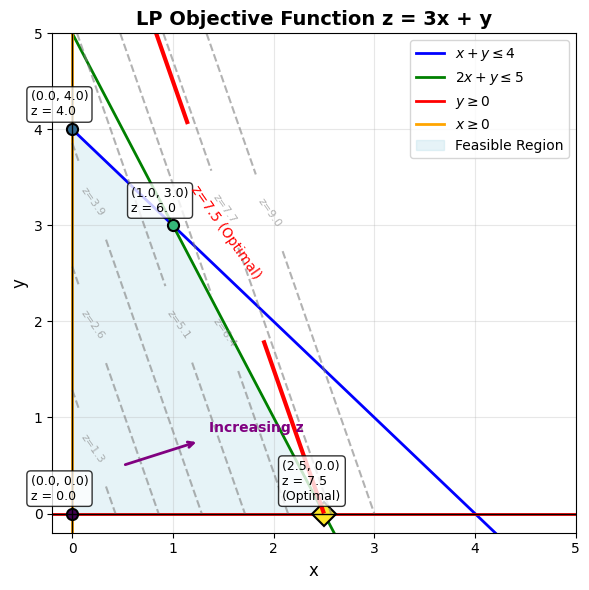

In [19]:
from viz_lp import plot_linear_programming_with_objective

fig, ax, vertices, optimal_point, optimal_value = (
    plot_linear_programming_with_objective(figsize=(6, 6))
)
plt.show()

从上图中我们可以看出：
- 在平面中总共有四个约束条件，每个约束条件都是一条直线
- 约束条件包围的区域就是可行域
- 可行域是一个凸起的多边形，最优解是这个多边形顶点中的一个
- 灰色虚线绘制的等高线是目标函数$ z=3x+y $ 的取值
- 当$z=7.5$时，$x=2.5$，$y=0$, 目标函数的最优解就是这个顶点

### 整数线性规划问题

整数线性规划要求决策变量取整数。下面在同一组约束和目标函数下，显示所有可行整数点，并与连续线性规划的松弛解进行比较。

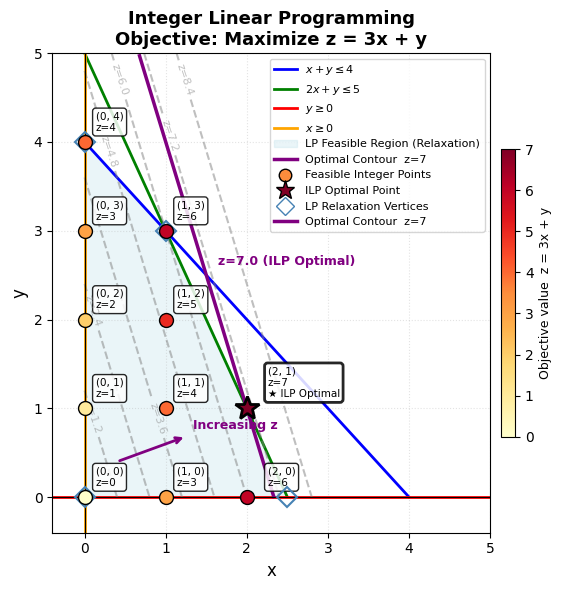

In [20]:
from viz_ilp import plot_integer_linear_programming

fig, ax, integer_points, optimal_point, optimal_value = (
    plot_integer_linear_programming(figsize=(6, 6))
)
plt.show()

从上图中可以看出：

- 浅蓝色区域是连续线性规划松弛问题的可行域。
- 圆点是满足约束的可行整数点，星形标记是整数最优解。
- 连续线性规划的最优解为 $(2.5, 0)$，目标函数值为 $7.5$。
- 整数线性规划的最优解为 $(2, 1)$，目标函数值为 $7$。

## 习题1（习题1-习题3任选1个完成）

某机床厂生产甲、乙两种机床，每台销售后的利润分别为 4000 元和 3000 元。生产甲机床需用 \(A\)、\(B\) 刀具加工，加工时间分别为每台 2 小时和 1 小时；生产乙机床需用 \(A\)、\(B\)、\(C\) 三种刀具加工，加工时间分别为每台 1 小时、1 小时和 1 小时。若每天可用于加工的刀具时数分别为 \(A\) 刀具 10 小时，\(B\) 刀具 8 小时和 \(C\) 刀具 7 小时，问该厂应生产甲、乙机床各几台，才能使总利润最大？

目标函数为：

$$ 
\text{max } z = 4000x_1 + 3000x_2 \tag{3-1}  
$$ 

约束条件为：  
$$ 
\begin{aligned}  
2x_1 + x_2 &\leq 10 \tag{3-2} \\
x_1 + x_2 &\leq 8   \\
x_2 &\leq 7 \\
x_1, x_2 &\geq 0  
\end{aligned}  
$$



In [21]:
# UNQ_C1 (不要修改这两行注释，否则该习题无法生成报告)
# GRADED FUNCTION: solve_machine_production_lp

from pulp import *

def solve_machine_production_lp():


    # 大约需要 11 行代码
    # 你编写的代码从这里开始
    # 定义问题：最大化目标函数
    problem = LpProblem(...)

    # 定义决策变量：甲机床 x、乙机床 y
    x = LpVariable(...)
    y = LpVariable(...)

    # 定义目标函数
    problem += ...

    # 添加约束条件
    problem += ...
    problem += ...
    problem += ...

    # 求解
    ...

    # 输出结果， status要求返回字符串
    status = ...
    optimal_x = ...
    optimal_y = ...
    optimal_profit = ...

    # 你编写的代码到这里结束
    result = {
        'status': status,
        '甲机床生产数量': optimal_x,
        '乙机床生产数量': optimal_y,
        '总利润': optimal_profit
    }
    return result

In [22]:
solve_machine_production_lp()

# 输出结果应该为：
#  {'status': 'Optimal', '甲机床生产数量': 2.0, '乙机床生产数量': 6.0, '总利润': 4000*x + 3000*y + 0}

TypeError: argument of type 'ellipsis' is not iterable

In [23]:
# 测试习题1
testsuite3.test_solve_machine_production_lp(solve_machine_production_lp)

测试失败 test_solve_machine_production_lp: argument of type 'ellipsis' is not iterable


## 习题2

求解如下形式的一般线性规划问题：

$$
\begin{array}{rll}
\max & c_{0}x_0 + \cdots + c_{n-1}x_{n-1} \\[8pt]
\text{s.t.} & a_{0,0}x_0 + \cdots + a_{0,n-1}x_{n-1} & \leq b_0 \\[8pt]
& \vdots & \\[8pt]
& a_{m-1,0}x_0 + \cdots + a_{m-1,n-1}x_{n-1} & \leq b_{m-1}
\end{array}
$$

注意：为了方便 Python 程序员，我们的索引从 0 开始。

该线性规划问题有 $n$ 个决策变量 $x_0, x_1, \ldots, x_{n-1}$，以及 $m$ 个约束。

问题的数据将以三个列表的形式给出：

- **list_c** 是一个大小为 `n` 的列表，包含目标函数的系数。  
  示例：  
  ```
  list_c: [c0, ..., cn-1]
  ```

- **list_a** 是一个包含 $m$ 个列表的列表，其中每个子列表的大小为 $n$，表示所有约束的系数。  
  示例：  
  ```
  list_a: [ [a00, a01, ..., a0,n-1], 
            [a10, a11, ..., a1,n-1], 
            ...,
            [am-1,0, ..., am-1,n-1] ]
  ```

- **list_b** 是一个大小为 `m` 的列表，包含各不等式右侧的常数项。  
  示例：  
  ```
  list_b: [b0, ..., bm-1]
  ```

你的目标如下：

- 给定 `list_c`、`list_a` 和 `list_b`，使用 PULP 设置这个线性规划问题；
- 求解该问题；
- 返回结果。结果由一个包含三部分的元组构成：(is_feasible, is_bounded, opt_sol)。
  - **is_feasible** 是一个布尔值：如果线性规划问题可行，则为 `True`，否则为 `False`。
  - **is_bounded** 是一个布尔值：如果线性规划问题有界，则为 `True`，否则为 `False`。当且仅当 **is_feasible** 为 `True` 时，这个值才有意义。如果 **is_feasible** 为 `False`，此值可以是任意的。
  - **opt_sol** 是一个包含 `n` 个决策变量取值的列表，即 $x_0, x_1, \ldots, x_{n-1}$。当且仅当 **is_feasible** 和 **is_bounded** 均为 `True` 时，**opt_sol** 的值才有意义。如果不满足这些条件，其值可以是任意的。
```


In [ ]:
# UNQ_C1 (不要修改这两行注释，否则该习题无法生成报告)
# GRADED FUNCTION: formulate_lp_problem

from pulp import *

def formulate_lp_problem(m, n, list_c, list_a, list_b):
    # Assert that the data is compatible.
    assert n > 0
    assert m > 0
    assert len(list_c) == n
    assert len(list_a) == len(list_b) and len(list_b) == m
    assert all(len(l) == n for l in list_a)


    # 大约需要 10 行代码

    # 你编写的代码从这里开始
    ## 1. 创建一个线性规划问题
    problem = LpProblem(...)
    ## 2. 创建决策变量
    decision_vars = ...
    ## 3. 创建目标函数
    object_function = ...
    ## 4. 添加约束条件, 共有m个约束条件
    ...

    ## 5. 求解
    ...

    ## 6. 提取解
    sols = ...
    is_feasible = ...
    is_bounded = ...

    # 你编写的代码到这里结束

    ## 打印并返回结果
    return is_feasible, is_bounded, sols

In [ ]:
# 测试习题2
testsuite3.test_formulate_lp_problem(formulate_lp_problem)

## 习题3

欢迎来到金融世界！
我们对投资一个多样化的股票组合感兴趣，希望最大化投资的总回报(利润/收益)，同时我们也希望投资是多样化的，且市盈率(PE)不能太高等，以降低风险。在这个问题中，我们将使用线性规划来构建投资组合。

- 给定可用的总预算为 $B > 0$
- 我们还获得了一系列可能的股票及其相关数据。每个投资的数据包括：
  - 每项投资的预期回报
  - 股票的当前单位价格
  - 股票的最近单位收益
  - 投资的市场类别：大宗商品、科技、医疗保健

你的目标是根据给定数据制定一个线性规划问题，以最大化总体预期回报，同时需要满足以下约束：
  - 投资总成本必须小于或等于 $B$
  - 只允许购买非负数量($\geq 0$)的每种股票(不允许卖空)。你可以购买股票的零散份额(这很有趣，但很多在线交易所都允许这样做)
  - 投资必须平衡：
    - 每个市场类别的投资额应小于或等于总预算的 2/3
    - 每个市场类别的投资额应至少为总预算的 1/6
  - 整体投资组合的市盈率不应超过 15
    - 市盈率计算公式：市盈率 = 股票的当前单位价格 / 股票的单位收益
    - 投资组合的市盈率 = 总的投资金额 / 总的收益(按照当前每股收益计算)

假设我们有以下六个投资，ID 为 1-6，数据(这些数据纯属虚构)如下表所示：

$$\begin{array}{|l|l|l|l|l|l|}
\hline
\text{ID} & \text{股票} & \text{单位价格} & \text{单位预期回报} & \text{每股收益} & \text{类别} \\ 
\hline 
1 & \text{IBM} & 129 & 25 & 1.9 & \text{科技} \\ 
2 & \text{META} & 286 & 20 & 8.1 & \text{科技} \\ 
3 & \text{阿斯利康} & 72.29 & 3 & 1.5 & \text{医疗} \\ 
4 & \text{辉瑞} & 38 & 1.5 & 5 & \text{医疗} \\ 
5 & \text{联合利华} & 52 & 3 & 2.5 & \text{大宗商品} \\ 
6 & \text{宝洁} & 148 & 4.50 & 5.2 & \text{大宗商品}\\
\hline
\end{array}$$

令 $x_1, \ldots, x_6$ 为决策变量，其中 $x_i$ 表示购买 ID 为 $i$ 的股票的数量。

请用 $x_1, \ldots, x_6$ 写出目标函数表达式。同时，说明我们是要最大化还是最小化它。将下面所有的数学公式中的问号改成具体的数字。

$$
\max (?x_1 +?x_2 +?x_3 + ?x_4 + ?x_5 + ?x_6)
$$

使用数学公式写下约束总的投资额必须小于等于 $B = 10,000$.

$$
?x_1 + ?x_2 + ?x_3 + ?x_4 +?x_5 + ?x_6 <= 10000
$$

写下约束每个类别的总投资额不能超过预算的 2/3。你应该写下三个约束，每个类别一个。

$
？x_1 +？x_2 <= 2/3 * 10000 
$

$
?x_3 + ?x_4 <=2/3 *10000
$

$
?x_5 + ?x_6 <= 2/3*10000
$

写下约束，每个类别的总投资额不能低于预算的 1/6。你应该写下三个约束，每个类别一个。

$
?x_1 + ?x_2 >= 1/6 * 10000 
$

$
?x_3 + ?x_4 >= 1/6 *10000
$

$
?x_5 + ?x_6 >= 1/6 *10000
$

投资组合的总成本表达式是：

$
?x_1 + ?x_2 + ?x_3 + ?x_4 + ?x_5 + ?x_6
$

投资组合的总收益的表达式是：

$
?x_1 + ?x_2 + ?x_3 + ?x_4 + ?x_5 +?x_6
$

我们希望强制执行的约束是，投资组合的总市盈率不能超过 15。将约束写成

$$ \text{Price} \leq 15 \times \text{Earnings} $$

将上面的表达式代入上面的公式：

$$
 ...  <= 15* (  ... )
$$

使用``pulp``库求解这个问题，并返回一个包含三个元素的元组，分别是：(is_feasible, is_bounded, opt_sol)。

In [ ]:
# UNQ_C3 (不要修改这两行注释，否则该习题无法生成报告)
# GRADED FUNCTION: solve_investment_problem

from pulp import *

def solve_investment_problem():

    # 大约需要 26 行代码
    # 你编写的代码从这里开始
    # 定义问题：最大化目标函数
    problem = LpProblem(...)

    # 定义决策变量：6只股票投资的股数
    x1 = LpVariable(...)
    x2 = LpVariable(...)
    ...

    # 定义目标函数
    problem += ...

    # 投资总额必须等于 10000的约束
    problem += ...

    # 每个类别的股票不能超过投资总额的2/3的约束
    problem += ...
    problem += ...
    problem += ...

    # 每个类别不能少于投资综合的1/6的约束
    problem += ...
    problem += ...
    problem += ...

    # 投资组合市盈率不能超过 15 的约束
    problem += ...

    # 求解
    ...

    # 输出结果, status返回字符串类型
    status = ...
    optimal_x1 = ...
    optimal_x2 = ...
    ...
    optimal_x6 = ...
    optimal_profit = ...

    # 你编写的代码到这里结束

    result = {
        'status': status,
        'x1': optimal_x1,
        'x2': optimal_x2,
        'x3': optimal_x3,
        'x4': optimal_x4,
        'x5': optimal_x5,
        'x6': optimal_x6,
        'profit': optimal_profit
    }
    return result

In [ ]:
solve_investment_problem()
# 输出结果应该为：
# {'status': 'Optimal',
#  'x1': 33.830665,
#  'x2': 0.0,
#  'x3': 0.0,
#  'x4': 104.45204,
#  'x5': 32.051282,
#  'x6': 0.0,
#  'profit': 1098.598531}

In [ ]:
# 测试习题3
testsuite3.test_solve_investment_problem(solve_investment_problem)

## 习题4

在你的学习生活中，或者在你玩过的游戏中是否有遇到过线性规划问题。像前面的习题一样，创建一个你自己的线性规划问题（可以借助AI），并尝试解决该问题。

在下面Markdown单元格中编写你的线性规划问题的描述：
- 目标函数是什么？
- 决策变量包括哪些？
- 约束条件是什么？

In [ ]:
# 习题4： 在这里给出一个求解该线性规划问题的代码


# 第二部分：整数线性规划

本部分在普通线性规划的基础上，继续学习整数变量和二元变量模型。

## 什么是整数线性规划问题

整数线性规划(Integer Linear Programming, ILP)是线性规划的一种特殊形式，其主要特点是:

- 目标函数是线性的
- 约束条件也是线性的
- 所有变量必须是整数

与普通线性规划的区别在于： 

- 普通线性规划允许变量取实数值, 决策变量的`cat`参数使用默认值`Continuous`
  - 例如： `x = LpVariable('x', cat='Continuous')`
- 整数线性规划要求变量只能取整数值, 决策变量的`cat`参数为`Binary`或者`Integer`
  - 决策变量只能是整数： `x = LpVariable('x', cat='Integer')`
  - 决策变量只能是0或者1： `x = LpVariable('x', cat='Binary')`

整数线性规划比普通线性规划更难求解，属于NP完全问题[什么是NP完全问题](https://baike.baidu.com/item/NP%E5%AE%8C%E5%85%A8%E9%97%AE%E9%A2%98)。整数线性规划问题也可以使用`pulp`库来求解，但是当变量很多时，求解速度可能会很慢。

## 糖果购买问题（背包问题的变种）

我们之前已经接触过 PuLP 作为求解线性规划的软件包。事实上，PuLP 也能有效解决整数线性规划问题。我们将通过几个案例来介绍如何使用 PuLP 建立和求解整数线性规划问题，其基本流程与解决线性规划问题非常相似，只需要确保将变量声明为整数或二元变量即可。


你在一家糖果店希望购买总重 100 克的糖果。我们需要选择购买的糖果类型（可以将其视为饮食问题的整数线性规划版本）。商店提供 $n$ 种不同的糖果品种 $D_1, \ldots, D_n$，选择时需要满足以下条件：

- 每种糖果 $D_j$ 最多可选 $k_j$ 个</li>
- 单颗 $D_j$ 类糖果的售价为 $p_j$</li>
- 单颗 $D_j$ 类糖果的热量为 $c_j$ 卡路里</li>
- 目标是最小化购买总成本</li>
- 糖果礼盒最多容纳 $N$ 颗糖，必须确保所有糖果能装入礼盒</li>
- 总卡路里摄入需满足最小值 $C_{\min}$ 且不超过最大值 $C_{\max}$</li>


由于必须选择整颗糖果，这个问题属于整数线性规划问题。已知参数包括：
- $n$：糖果种类数
- $(k_1, \ldots, k_n)$：各类糖果的最大可选数量
- $(p_1, \ldots, p_n)$：价格表
- $(c_1, \ldots, c_n)$：单位热量表
- $N$：礼盒容量限制
- $C_{\min}$ 和 $C_{\max}$：卡路里上下限



本问题决策变量为: $x_1, \ldots, x_n$
其中 $x_i$ 表示选择的第 $i$ 类糖果数量。各变量需满足：
$$ 0 \leq x_i \leq k_i,\ i = 1, \ldots, n $$
总数量约束：
$$ \sum_{i=1}^n x_i \leq N $$
热量约束：
$$ C_{\min} \leq \underbrace{\sum_{i=1}^n c_i x_i}_{\text{总摄入热量}} \leq C_{\max} $$

最终构建的整数线性规划模型为：
$$\begin{array}{rll}
\min& \sum_{j=1}^n p_j x_j & \leftarrow\ \text{最小化购买总成本} \\ 
\mathsf{s.t.} & 0 \leq x_j \leq k_j & \leftarrow\ \text{单类糖果数量限制} \\ 
& \sum_{j=1}^n x_j \leq N & \leftarrow\ \text{礼盒容量限制}\\ 
& C_{\min} \leq \sum_{i=1}^n c_i x_i  \leq C_{\max} & \leftarrow\ \text{热量区间限制} \\ 
& x_1, \ldots, x_n \in \mathbb{Z} & \leftarrow\ \text{整数约束}\\
\end{array}$$

接下来使用`pulp`库来求解整数线性规划问题。

In [ ]:
from pulp import *

def solve_candy_knapsack(n, candy_number_limits, candy_prices, candy_calories, N, Cmin, Cmax):
    assert len(candy_number_limits) == n, 'size mismatch'
    assert len(candy_prices) == n, 'size mismatch for prices'
    assert len(candy_calories) == n, 'size mismatch for list of calories'
    assert N >= 1, 'total number of candies per box must be 1 or more'
    assert Cmin <= Cmax, 'minimum calories is greater than the maximum calories'

    # 目标函数：最小化购买糖果的成本
    prob = LpProblem('Candy_Knapsack', LpMinimize)

    # 添加n个决策变量，每个变量代表购买某种糖果的数量，cat参数为'Integer', 表示变量为整数
    dVars = [LpVariable(f'x{i}',lowBound=0, upBound=ki, cat='Integer')
                for (i, ki) in enumerate(candy_number_limits)]

    # 设置目标函数，计算购买糖果的总成本，使用lpSum函数来计算
    prob += lpSum([pj*xj for (pj,xj) in zip(candy_prices, dVars)])

    # 添加约束，所有糖果的数量不超过N
    prob += lpSum(dVars) <= N

    # 计算购买糖果的总卡路里，添加约束，总卡路里在[Cmin, Cmax]之间
    calories_of_candies = lpSum([cj*xj for (cj,xj) in zip(candy_calories, dVars)])
    prob += calories_of_candies <= Cmax
    prob += calories_of_candies >= Cmin

    # 求解问题
    status = prob.solve(PULP_CBC_CMD(msg=False))

    # 输出结果
    if status == constants.LpStatusInfeasible:
        print('问题无解，无法找到满足约束条件的解')
        return
    elif status == constants.LpStatusUnbounded:
        print('问题无界')
        return
    else:
        assert status == constants.LpStatusOptimal, 'Something went wrong while solving since status is either undefined or unsolved'
        # extract values
        print('成功: 找到了最优解')
        solution_values = [x.varValue for x in dVars]
        for (j, svj) in enumerate(solution_values):
            print(f'\t 糖果种类 # {j}: {svj} 个糖果')

        print(f'总成本: {sum([(pj*svj) for (pj, svj) in zip(candy_prices, solution_values)])}')
        print(f'总的卡路里: {sum([cj*xj for (cj,xj) in zip(candy_calories, solution_values)])}')

In [ ]:
n = 5
candy_number_limits = [10, 12, 10, 11, 10]
candy_prices = [0.2, 0.5, 0.1, 0.4, 0.8]
candy_calories = [25, 12, 22, 14, 33]
solve_candy_knapsack(5, candy_number_limits, candy_prices, candy_calories, 12, 250, 500)

## 习题5（习题5-习题7任选2个完成）

工人指派问题

| 工人 | A   | B   | C   | D   |
|------|-----|-----|-----|-----|
| 甲   | 15  | 18  | 21  | 24  |
| 乙   | 19  | 23  | 22  | 18  |
| 丙   | 26  | 17  | 16  | 19  |
| 丁   | 19  | 21  | 23  | 17  |

问题：  
问分别指派哪名工人去完成哪一项工作（每个工人只能被指定一项工作），可使总的消耗时间为最小？总的消耗时间最少是多少？  

补全下面的函数解决这个问题，函数返回字典包含
- status: 线性规划问题的状态，类型是字符串，取值可能是'optimal', 'infeasible', 'unbounded'
- total_time: 最小的消耗时间，如果该问题无解或无界，则返回None

提示1： 该问题需要16个决策变量，每个决策变量的取值为0或1


In [ ]:
# UNQ_C5 (不要修改这两行注释，否则该习题无法生成报告)
# GRADED FUNCTION: solve_worker_assignment_lp

from pulp import *

def solve_worker_assignment_lp():

    # 定义工人和工作任务
    workers = ['甲', '乙', '丙', '丁']
    tasks = ['A', 'B', 'C', 'D']

    # 定义工人完成任务的时间表
    time_costs = {
        ('甲', 'A'): 15, ('甲', 'B'): 18, ('甲', 'C'): 21, ('甲', 'D'): 24,
        ('乙', 'A'): 19, ('乙', 'B'): 23, ('乙', 'C'): 22, ('乙', 'D'): 18,
        ('丙', 'A'): 26, ('丙', 'B'): 17, ('丙', 'C'): 16, ('丙', 'D'): 19,
        ('丁', 'A'): 19, ('丁', 'B'): 21, ('丁', 'C'): 23, ('丁', 'D'): 17
    }

    ## 你编写的代码从这里开始， 大约10-20行代码
    # 创建线性规划问题
    problem = LpProblem(...)

    # 创建16个决策变量
    x =   ...     #  创建一个与time_costs键相同的字典，值为决策变量，决策变量的cat参数为Binary（表示只能为0或者1）

    # 添加目标函数
    problem += ...

    # 添加八个约束条件，每个工人只能被分配一项任务，
    # 每项任务必须分配一个工人, 可以使用循环
    problem += ...

    # 求解问题
    ...

    # 输出结果
    status = ...
    total_time = ...   # 计算最小的消耗时间



    ## 你编写的代码到这里结束

    result = {
        'status': status,
        'total_time': total_time
    }
    return result

In [ ]:
solve_worker_assignment_lp()
# 调用你的函数，预期输出应该为：
# {'status': 'Optimal', 'total_time': 70.0 }

In [ ]:
testsuite3.test_solve_worker_assignment_lp(solve_worker_assignment_lp)

## 习题6（整数线性规划）

集合覆盖问题

---

假设你正在计划一个公司派对，有 $n$ 个人按 $1, \ldots, n$ 编号，这些人都可能被邀请。我们希望邀请至少 $m$ 个人参加。因此，人力资源部要求你遵守以下限制：

有多个员工团队 $T_1, \ldots, T_k$，其中 $T_i \subseteq \{1, \ldots, n\}$ 是员工的子集。一个员工可以属于多个团队。我们希望确保每个团队至少有 1/4 的成员被邀请。注意，同一个人可以作为多个团队的代表被邀请。

我们还有一组对 $G_1, \ldots, G_l$，其中每个 $G_j$ 由一组有互相争议的员工组成。为了保持派对的欢乐氛围，我们不能从每个争议集 $G_j$ 中邀请超过一名员工。

人力资源部门通过其机器学习算法为每位员工 $i$ 分配了一个"扫兴"分数 $s_i$，分数越高，他们就越可能扫兴。我们希望最小化所有被邀请员工的总扫兴分数。

决策变量：我们将有决策变量 $w_1, \ldots, w_n$，其中 $w_i = 1$ 表示员工 $i$ 被邀请参加派对，$w_i = 0$ 表示他们未被邀请。

目标函数：$\min\ \sum_{i=1}^n s_i w_i$，其中 $s_i$ 是员工 $i$ 的"扫兴"分数。

约束条件：我们将有以下约束：

- $\sum_{j \in T_i} w_j \geq |T_i|/4\ \text{对每个}\ T_i$ (每个团队至少四分之一的成员)
- $\sum_{j \in G_i} w_j \leq 1\ \text{对每个}\ G_i$ (每个争议集最多一人)
- $\sum_{j=1}^n w_j \geq m$ (总共至少邀请 $m$ 人)
- $w_j \in \{0, 1\}$ 对所有 $j \in \{1, \ldots, n\}$ (二元变量)


In [ ]:
# UNQ_C6 (不要修改这两行注释，否则该习题无法生成报告)
# GRADED FUNCTION: plan_invite_list

from pulp import *
def plan_invite_list(n, m, T_lists, G_lists, pp_scores):
    assert m >= 0, '邀请的员工人数不能是负数'
    assert all( 0 <= j < n for ti in T_lists for j in ti )
    assert all( 0<= j < n for gi in G_lists for j in gi)
    assert len(pp_scores) == n, '扫兴分数列表的长度不等于员工数'


    ## 你编写的代码从这里开始, 大约15-20行代码
    # 创建线性规划问题
    problem = LpProblem(...)

    # 创建n个决策变量，存放在一个list中，0表示该索引序号的员工不被邀请，
    # 1表示该索引序列的员工被邀请
    dvars =   [LpVariable(...) for i in range(n) ]

    # 添加目标函数，计算总的扫兴分数
    problem += ...

    # 添加若干个约束条件，每个小组至少1/4的员工被邀请，每个争议集合最多邀请一个人，
    # 至少需要邀请m个人
    problem += ...


    # 求解问题
    ...

    # 输出结果
    status = ...     # 表示线性规划问题状态的整数值
    # 返回由0和1组成的列表，0表示该索引序号的员工不被邀请，1表示该索引序列的员工被邀请
    # 如果问题无解，则返回空数组：[ ]
    solution = ...
    optimal_pop_score = ...    # 返回问题的目标函数的值，也就是最优的扫兴分数

    ## 你编写的代码到这里结束
    return status, solution, optimal_pop_score


In [ ]:
testsuite3.test_plan_invite_list(plan_invite_list)

## 习题7（整数线性规划）

在这个问题中，你将把三着色问题设置并求解为整数线性规划问题。

三着色问题输入一个无向图 $G$，其顶点集为 $V = \{1, \ldots, n\}$ 且有无向边集 $E$。我们要寻找一种方法，将每个顶点染成红色、绿色或蓝色三种颜色之一，使得任意边 $(i,j)$ 的两个端点 $i,j$ 具有不同的颜色。

给定一个图，我们希望知道是否存在一个三着色方案，如果存在，我们希望找到这个三着色方案。虽然这看起来像是一个玩具问题，但它在资源分配和其他领域都有实际应用。

首先，我们要求你将三着色问题设置为整数线性规划问题。

决策变量：对于每个顶点 $i \in V$，我们将使用三个决策变量 $x_i^R, x_i^G$ 和 $x_i^B$ 来分别表示该顶点是否被染成红色、绿色或蓝色。注意，这些都是取值为 $0,1$ 的二进制变量。

### (A) 每个顶点只能取一种颜色

用 $x_i^R, x_i^G$ 和 $x_i^B$ 写出一个约束条件（？是你需要填写的内容），表示每个顶点必须恰好被染成红色、绿色或蓝色三种颜色之一。

$x_i^R + x_i^G + x_i^B = ?$

### (B) 相邻顶点不能具有相同的颜色

对于每条边 $(i,j) \in E$，写出表示它们不能具有相同颜色的约束条件。**提示**: 写出三个约束条件，分别表示顶点 $i,j$ 不能同时为绿色、不能同时为红色以及不能同时为蓝色。将这些要求转换为涉及 $x_i^G, x_j^G$， $x_i^R, x_j^R$ 和 $x_i^B, x_j^B$ 的约束条件。


约束条件一：
$$
x_i^G + x_j^G <= ? 
$$

再写两个约束条件：
$$
???  \\
???
$$

编写一个函数，该函数接受顶点数量 $n \geq 1$ 和边列表（以顶点对的列表形式给出）`[ (i1, j1), (i2, j2) ..., (im, jm) ]` 作为输入，返回一个元组 `(flag, color_assignment)`，其中包含布尔值 `flag` 和列表 `color_assignment`，具体要求如下：

- `flag` 如果图是可三着色的则为 `True`，否则为 `False`。
- `color_assignment` 是一个包含 n 个颜色的列表，颜色用 `r`、`g` 或 `b`（分别代表红色、绿色或蓝色）表示，列表中第 $i$ 个元素表示分配给顶点 $i$ 的颜色。

注意：
- 如果 `flag` 设置为 `False`，则返回值中的 `color_assignment` 部分将被忽略。
- 这个线性规划问题不需要目标函数。

In [ ]:
# UNQ_C7 (不要修改这两行注释，否则该习题无法生成报告)
# GRADED FUNCTION: encode_and_solve_three_coloring

from pulp import *

def encode_and_solve_three_coloring(n, edge_list):
    assert n >= 1, 'Graph must have at least one vertex'
    assert all(0 <= i and i < n and 0 <= j and j < n and i != j for (i, j) in edge_list), 'Edge list is not well formed'

    ## 你编写的代码从这里开始，大约20-30行代码, 将... 替换为正确的代码
    # 创建线性规划问题
    problem = LpProblem(...)

    # 创建三个长度为n个决策变量list，reds列表中的1表示该索引节点选中的颜色为红色，0表示不是红色，
    # green和blues列表也是类似的意思
    reds = [LpVariable(...) for i in range(n)]
    greens = ...
    blues = ...

    # 添加约束条件，每个节点只能选中一种颜色
    problem += ...

    ## 遍历边列表，添加约束，相邻节点不可以是相同颜色
    for i, j in edge_list:
        problem += ...
        problem += ...
        problem += ...


    ## 求解问题
    status = ...

    # 输出结果，如果有最优解，返回True和颜色列表, 颜色列表应该只包含'r','g',或者'b'
    color_assignment = []  # 初始化颜色列表
    if status == ... :
        flag = ...
        for i in ...:
            if ...:
                ...
            elif ...:
                ...
            else:
                ...

    ## 如果没有解
    else:
        flag = ...

    ## 你编写的代码到这里结束
    return flag, color_assignment

In [ ]:
testsuite3.test_encode_and_solve_three_coloring(encode_and_solve_three_coloring)

## 实验讨论

请就下面的问题进行小组讨论，将讨论的内容记录下来。

- 问题1： 线性规划问题的基本结构是什么？应该包含哪些部分？条件约束部分满足什么条件，这个问题才能成为一个线性规划问题？
- 问题2： 在解决线性规划问题时，最后的结果的状态有哪些情况？不同的状态分别代表什么含义？
- 问题3： 完成所有实验，生成实验报告的pdf文件后，请将实验报告上传给AI生成本次实验的测验，检测一下自己本次实验的掌握程度。（请保存与AI对话的记录的链接，并上传到实验报告收集表）

### 整数线性规划部分

- 问题1： 整数线性规划问题和一般线性规划问题的区别在哪里？为什么解决整数规划问题会比普通线性规划问题慢？
- 问题2： 整数线性规划问题是NP难问题，什么是NP难问题？查阅资料，有哪些方法可以解决整数线性规划问题？

## 生成实验报告

将实验报告pdf文件提交到对应的班级和实验的腾讯文档收集表:[文档汇总地址](https://docs.qq.com/doc/DWUxJanVwYXFpZmF2)

In [ ]:
import importlib
import notebook2pdf
importlib.reload(notebook2pdf)

stu_grade = testsuite3.grade_all_tests(notebook_file)
pdf_file = f"{stu_info['class_id']}-{stu_info['student_id']}-{stu_info['name']}-实验报告3-{stu_grade}.pdf"
notebook2pdf.convert_notebook_to_webpdf(notebook_file, pdf_file)

正在从 notebook 文件收集测试函数: /Users/zhoujason/Desktop/Projects/data-modeling-course-student/实验03-线性规划/实验3-线性规划.ipynb
测试失败 test_solve_machine_production_lp: argument of type 'ellipsis' is not iterable
测试失败 test_formulate_lp_problem: argument of type 'ellipsis' is not iterable
测试失败 test_solve_investment_problem: argument of type 'ellipsis' is not iterable
测试失败 test_solve_worker_assignment_lp: argument of type 'ellipsis' is not iterable
测试失败 test_plan_invite_list: argument of type 'ellipsis' is not iterable
测试失败 test_encode_and_solve_three_coloring: argument of type 'ellipsis' is not iterable

最终测试结果:
通过 0 / 6 个测试
自动评分成绩(百分制): 0


Notebook to PDF: 100%|██████████| 100/100 [00:05<00:00, 17.33%/s]



成功生成报告文件: 25智能-未填写-未填写-实验报告3-0.pdf


In [ ]:
from report_submission import submit_pdf_report

receipt = submit_pdf_report(
    pdf_file,
    stu_info,
    experiment_number=3,
)

receipt

报告提交成功: dae32447-e547-44c1-bb69-da299318987e (version 2)


{'submission_id': 'dae32447-e547-44c1-bb69-da299318987e',
 'course_run_id': '2026-fall',
 'class_id': '25智能',
 'submitted_class_id': '25智能',
 'experiment_id': 'exp-03',
 'experiment_name': '实验三',
 'student_id': '未填写',
 'student_name': '未填写',
 'version': 2,
 'status': 'accepted',
 'original_filename': '25智能_未填写_未填写_实验三.pdf',
 'size_bytes': 4367119,
 'sha256': '50ed01e1a6fc661b0a7e88ad5628f0314dce08c268fe1a3cb83e8c566d8d8da6',
 'declared_media_type': 'application/pdf',
 'received_at': '2026-09-14T01:34:53.698641Z',
 'is_late': False,
 'supersedes_submission_id': 'c977790a-1243-47d4-a354-ed5a209db125',
 'collection_status': 'collected',
 'reboot_safe': False,
 'identity_status': 'unverified',
 'roster_match': False,
 'receipt_url': '/api/v1/submissions/dae32447-e547-44c1-bb69-da299318987e/receipt',
 'message': 'Submission collected locally; back it up before reboot.',
 'student_email': '123456@qq.com',
 'effective_status': 'current',
 'is_invalidated': False,
 'file_available': True}